# Grid plotting and export

**What this shows:** the plotting options of `RegularGrid` and how to save a grid to
GIS formats and load it back.

**Prerequisites:** [Tutorial 2: Defining the model grid](../tutorial/02_model_grid.ipynb).

**You will learn:**

- how to control coastlines, projections and the mesh overlay in `grid.plot()`
- how to draw other data on the same map
- how to export a grid to KML or GeoJSON and recreate it from the file

**Data used:** none (coastlines are downloaded by cartopy on first use).

## Setup

In [1]:
import shutil
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import matplotlib.pyplot as plt
from rompy.logging import config as logging_config
from rompy_xbeach.grid import RegularGrid

logging_config.update(level="WARNING")  # hide info messages from file writers

OUT_DIR = Path("_output") / "grid_plotting_and_export"
shutil.rmtree(OUT_DIR, ignore_errors=True)
OUT_DIR.mkdir(parents=True)

grid = RegularGrid(
    ori={"x": 115.594239, "y": -32.641104, "crs": 4326},
    alfa=347.0,
    dx=10.0,
    dy=15.0,
    nx=230,
    ny=220,
    crs=28350,
)

## 1. Coastline resolution

`scale` picks the GSHHS coastline resolution: `"c"` (crude), `"l"`, `"i"`, `"h"` or
`"f"` (full). Coarse coastlines draw faster, and full resolution is closest to a
beach-scale grid.

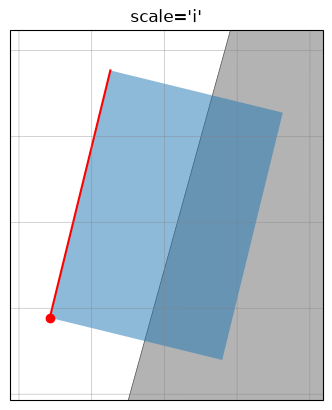

In [2]:
ax = grid.plot(scale="i")
ax.set_title("scale='i'")
plt.show()

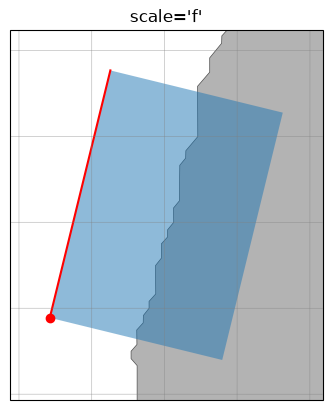

In [3]:
ax = grid.plot(scale="f")
ax.set_title("scale='f'")
plt.show()

With `scale=None` no coastline is drawn, so you can add your own features, such as
Natural Earth land polygons.

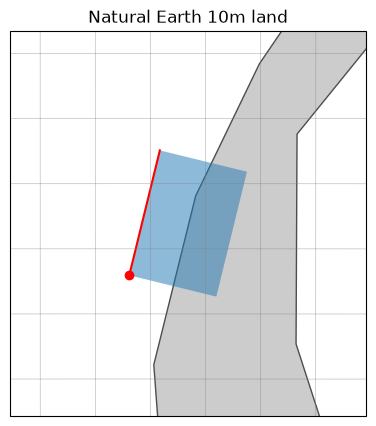

In [4]:
fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={"projection": grid.projection})
ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="0.8", edgecolor="0.3")
grid.plot(ax=ax, scale=None, buffer=3000)
ax.set_title("Natural Earth 10m land")
plt.show()

## 2. Mesh, colours and projection

`show_mesh` draws every `mesh_step`-th grid line. `grid_kwargs` and `mesh_kwargs`
style the grid polygon and the mesh lines.

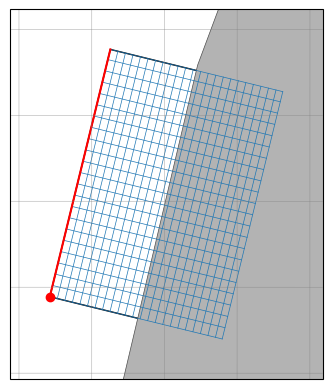

In [5]:
ax = grid.plot(
    scale="h",
    show_mesh=True,
    mesh_step=10,
    grid_kwargs={"facecolor": "none", "edgecolor": "black"},
    mesh_kwargs={"color": "tab:blue", "linewidth": 0.5},
)

By default the map uses a stereographic projection centred on the grid. Any cartopy
projection can be passed instead, for example plain longitude and latitude.

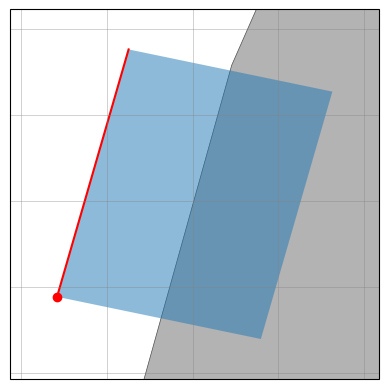

In [6]:
ax = grid.plot(scale="h", projection=ccrs.PlateCarree())

## 3. Drawing other data on the same map

`grid.transform` is the cartopy CRS of the grid coordinates, so anything in grid
coordinates can be added to the axes. Here a cross-shore transect is drawn in the
middle of the grid.

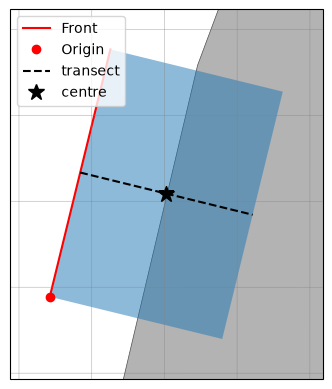

In [7]:
ax = grid.plot(scale="h")
iy = grid.ny // 2
ax.plot(grid.x[iy, :], grid.y[iy, :], "k--", transform=grid.transform, label="transect")
ax.plot(*grid.centre, "k*", markersize=12, transform=grid.transform, label="centre")
ax.legend(loc="upper left")
plt.show()

## 4. Export and reload

`to_file()` writes the grid cells with any GeoPandas driver, and stores the grid
definition in the file so `RegularGrid.from_file()` can rebuild the object. KML
opens directly in Google Earth.

In [8]:
kml = OUT_DIR / "grid.kml"
grid.to_file(kml, driver="KML")
reloaded = RegularGrid.from_file(kml)
print(reloaded)
print("Same grid:", reloaded == grid)

RegularGrid(ori=GeoPoint(x=115.594239, y=-32.641104, crs='EPSG:4326'), alfa=347.0, dx=10.0, dy=15.0, nx=230, ny=220, crs='EPSG:28350')
Same grid: True


For a lightweight outline, save just the boundary polygon.

In [9]:
outline = gpd.GeoSeries([grid.boundary()], crs=grid.crs)
outline.to_file(OUT_DIR / "grid_outline.geojson", driver="GeoJSON")
outline.to_crs(4326).iloc[0].wkt[:120] + " ..."

'POLYGON ((115.61795041877659 -32.64601374143588, 115.594239 -32.64110399999999, 115.60256410142583 -32.612326379211666,  ...'

## Summary

- `grid.plot()` takes `scale`, `projection`, `show_mesh` and styling arguments, and
  draws onto existing axes with `ax=`.
- `grid.transform` lets you overlay anything given in grid coordinates.
- `to_file()` and `from_file()` round-trip a grid through GIS formats.